# 🌤️ AI Weather Prediction System
### Machine Learning Pipeline — Nepal 293 Cities (2021–2024)

---

**Project:** Time-Series Weather Forecasting using Machine Learning  
**Dataset:** Nepal 293 Cities Weather Data (2021–2024)  
**Target:** Predict next-day Temperature, Precipitation, and Relative Humidity  
**Models:** Decision Tree · Random Forest · Support Vector Regression (SVR)  

---

## 1. Import Libraries

In [4]:
#  Standard Library
import os
import warnings
warnings.filterwarnings('ignore')

#  Data Manipulation
import numpy as np
import pandas as pd

# ── Visualisation
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

#  Scikit-learn: Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

#  Scikit-learn: Models
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression

#  Scikit-learn: Tuning & Evaluation
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Model Persistence
import joblib

# Notebook Display Helpers
from IPython.display import display
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.4f}'.format)

#  Plot Style
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({'figure.dpi': 100, 'figure.figsize': (12, 5)})

print('✅ All libraries imported successfully!')
print(f'   NumPy  {np.__version__}  |  Pandas  {pd.__version__}')

✅ All libraries imported successfully!
   NumPy  2.1.3  |  Pandas  2.2.3


## 2. Load Dataset

In [5]:
# Path Configuration
DATA_PATH   = '/content/nepal_293_cities_weather_2020_2025.csv'
MODEL_DIR   = '../models'
os.makedirs(MODEL_DIR, exist_ok=True)

#  Load CSV
print('⏳ Loading dataset …')
df_raw = pd.read_csv(DATA_PATH)

print(f'✅ Dataset loaded!')
print(f'   Shape : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
print(f'   Memory: {df_raw.memory_usage(deep=True).sum() / 1024**2:.1f} MB')
df_raw.head()

⏳ Loading dataset …
✅ Dataset loaded!
   Shape : 426,215 rows × 21 columns
   Memory: 129.2 MB


,Date,City,District,Latitude,Longitude,Precip,Pressure,Humidity_2m,RH_2m,Temp_2m,WetBulbTemp_2m,MaxTemp_2m,MinTemp_2m,EarthSkinTemp,WindSpeed_10m,MaxWindSpeed_10m,MinWindSpeed_10m,WindSpeed_50m,MaxWindSpeed_50m,MinWindSpeed_50m,Temp_2m_tomorrow
0,19/07/2020,Sanphebagar,Achham,29.1200,81.3000,17.9000,86.9300,19.6900,93.4800,23.5900,23.0000,25.7000,21.3500,23.6900,2.3100,3.4700,0.9300,3.1000,4.8900,1.5000,24.2400
1,20/07/2020,Sanphebagar,Achham,29.1200,81.3000,0.0000,86.7900,19.6800,90.3400,24.2400,23.3200,27.6800,21.8200,24.7300,2.7800,4.8000,1.5400,3.7500,5.3200,2.4300,23.3300
2,21/07/2020,Sanphebagar,Achham,29.1200,81.3000,15.4000,87.0900,18.5200,90.0800,23.3300,22.4000,26.7900,21.0800,23.6400,2.1100,4.0800,0.2000,2.7000,4.4600,0.2000,23.5800
3,22/07/2020,Sanphebagar,Achham,29.1200,81.3000,9.4000,87.1000,17.3100,83.2900,23.5800,21.9600,27.5100,20.6100,23.6800,1.5200,3.3100,0.2700,1.7200,3.1900,0.4000,22.6300
4,23/07/2020,Sanphebagar,Achham,29.1200,81.3000,22.3000,87.1700,17.3500,88.1300,22.6300,21.5200,26.2400,20.1700,22.8500,1.9400,4.3400,0.3200,2.6100,4.8400,0.3000,22.3700


## 3. Dataset Inspection

In [6]:
#  Column Overview
print('=== Column Info ===')
df_raw.info()
print()

=== Column Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426215 entries, 0 to 426214
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Date              426215 non-null  object 
 1   City              426215 non-null  object 
 2   District          426215 non-null  object 
 3   Latitude          426215 non-null  float64
 4   Longitude         426215 non-null  float64
 5   Precip            426215 non-null  float64
 6   Pressure          426215 non-null  float64
 7   Humidity_2m       426215 non-null  float64
 8   RH_2m             426215 non-null  float64
 9   Temp_2m           426215 non-null  float64
 10  WetBulbTemp_2m    426215 non-null  float64
 11  MaxTemp_2m        426215 non-null  float64
 12  MinTemp_2m        426214 non-null  float64
 13  EarthSkinTemp     426214 non-null  float64
 14  WindSpeed_10m     426214 non-null  float64
 15  MaxWindSpeed_10m  426214 non-null  float64
 16  

In [7]:
# Descriptive Statistics
print('=== Descriptive Statistics ===')
display(df_raw.describe().T)

=== Descriptive Statistics ===


,count,mean,std,min,25%,50%,75%,max
Latitude,426215.0000,27.5928,0.8439,26.6000,26.9300,27.5500,28.0800,30.1300
Longitude,426215.0000,84.7199,2.1237,80.3300,83.4500,85.3000,86.2000,88.0800
Precip,426215.0000,4.1477,10.0377,0.0000,0.0000,0.0000,2.9000,199.4000
Pressure,426215.0000,90.4206,9.0275,54.2200,87.0200,91.8600,97.9900,101.2600
Humidity_2m,426215.0000,11.5698,5.9036,0.5600,6.2900,10.4500,17.0700,24.5200
RH_2m,426215.0000,65.7946,21.3452,6.5300,48.6100,69.7000,85.3700,99.7600
Temp_2m,426215.0000,20.5178,7.5426,-24.2300,15.6100,21.3400,26.6400,39.4300
WetBulbTemp_2m,426215.0000,16.4776,7.8396,-25.1800,11.3000,16.9600,22.7600,30.3800
MaxTemp_2m,426215.0000,25.8641,7.4132,-14.2000,21.3300,26.1700,30.8300,47.2000
MinTemp_2m,426214.0000,16.2707,7.6641,-34.5000,11.2600,16.9800,22.5000,32.9400


In [8]:
# Unique Counts
print(f'Unique Cities    : {df_raw["City"].nunique()}')
print(f'Unique Districts : {df_raw["District"].nunique()}')
print(f'Date column sample values:')
print(df_raw['Date'].head(5).tolist())

Unique Cities    : 275
Unique Districts : 68
Date column sample values:
['19/07/2020', '20/07/2020', '21/07/2020', '22/07/2020', '23/07/2020']


In [9]:
# Missing Value Heatmap
missing = df_raw.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.any() else '✅ No missing values found!')

Missing values per column:
MinTemp_2m          1
EarthSkinTemp       1
WindSpeed_10m       1
MaxWindSpeed_10m    1
MinWindSpeed_10m    1
WindSpeed_50m       1
MaxWindSpeed_50m    1
MinWindSpeed_50m    1
Temp_2m_tomorrow    1
dtype: int64


## 4. Data Cleaning

In [10]:
df = df_raw.copy()

# Parse Dates
# Dataset uses DD/MM/YYYY format
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y', errors='coerce')
unparsed = df['Date'].isna().sum()
print(f'Unparseable date rows: {unparsed}')
df = df.dropna(subset=['Date'])

# Province Mapping
DISTRICT_TO_PROVINCE = {
    # Koshi Province
    'Bhojpur': 'Koshi', 'Dhankuta': 'Koshi', 'Ilam': 'Koshi', 'Jhapa': 'Koshi',
    'Khotang': 'Koshi', 'Morang': 'Koshi', 'Okhaldhunga': 'Koshi', 'Panchthar': 'Koshi',
    'Sankhuwasabha': 'Koshi', 'Solukhumbu': 'Koshi', 'Sunsari': 'Koshi', 'Taplejung': 'Koshi',
    'Terhathum': 'Koshi', 'Udayapur': 'Koshi',
    # Madhesh Province
    'Bara': 'Madhesh', 'Dhanusha': 'Madhesh', 'Mahottari': 'Madhesh', 'Parsa': 'Madhesh',
    'Rautahat': 'Madhesh', 'Saptari': 'Madhesh', 'Sarlahi': 'Madhesh', 'Siraha': 'Madhesh',
    # Bagmati Province
    'Bhaktapur': 'Bagmati', 'Chitwan': 'Bagmati', 'Dhading': 'Bagmati', 'Dolakha': 'Bagmati',
    'Kathmandu': 'Bagmati', 'Kavrepalanchok': 'Bagmati', 'Lalitpur': 'Bagmati',
    'Makwanpur': 'Bagmati', 'Nuwakot': 'Bagmati', 'Ramechhap': 'Bagmati',
    'Rasuwa': 'Bagmati', 'Sindhuli': 'Bagmati', 'Sindhupalchok': 'Bagmati',
    # Gandaki Province
    'Baglung': 'Gandaki', 'Gorkha': 'Gandaki', 'Kaski': 'Gandaki', 'Lamjung': 'Gandaki',
    'Manang': 'Gandaki', 'Mustang': 'Gandaki', 'Myagdi': 'Gandaki', 'Nawalpur': 'Gandaki',
    'Parbat': 'Gandaki', 'Syangja': 'Gandaki', 'Tanahun': 'Gandaki',
    # Lumbini Province
    'Arghakhanchi': 'Lumbini', 'Banke': 'Lumbini', 'Bardiya': 'Lumbini', 'Dang': 'Lumbini',
    'Gulmi': 'Lumbini', 'Kapilvastu': 'Lumbini', 'Parasi': 'Lumbini', 'Palpa': 'Lumbini',
    'Pyuthan': 'Lumbini', 'Rolpa': 'Lumbini', 'Rupandehi': 'Lumbini', 'East Rukum': 'Lumbini',
    # Karnali Province
    'Dailekh': 'Karnali', 'Dolpa': 'Karnali', 'Humla': 'Karnali', 'Jajarkot': 'Karnali',
    'Jumla': 'Karnali', 'Kalikot': 'Karnali', 'Mugu': 'Karnali', 'Salyan': 'Karnali',
    'Surkhet': 'Karnali', 'West Rukum': 'Karnali',
    # Sudurpashchim Province
    'Achham': 'Sudurpashchim', 'Baitadi': 'Sudurpashchim', 'Bajhang': 'Sudurpashchim',
    'Bajura': 'Sudurpashchim', 'Dadeldhura': 'Sudurpashchim', 'Darchula': 'Sudurpashchim',
    'Doti': 'Sudurpashchim', 'Kailali': 'Sudurpashchim', 'Kanchanpur': 'Sudurpashchim'
}

df['Province'] = df['District'].map(DISTRICT_TO_PROVINCE).fillna('Unknown')

# Remove Duplicates
before = len(df)
df = df.drop_duplicates(subset=['Date', 'City'])
print(f'Duplicates removed: {before - len(df)}')

# Sort Chronologically
df = df.sort_values(by=['City', 'Date']).reset_index(drop=True)

print(f'\n✅ Cleaning complete!')
print(f'   Final shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

Unparseable date rows: 0
Duplicates removed: 6578

✅ Cleaning complete!
   Final shape: 419,637 rows × 22 columns


,Date,City,District,Latitude,Longitude,Precip,Pressure,Humidity_2m,RH_2m,Temp_2m,WetBulbTemp_2m,MaxTemp_2m,MinTemp_2m,EarthSkinTemp,WindSpeed_10m,MaxWindSpeed_10m,MinWindSpeed_10m,WindSpeed_50m,MaxWindSpeed_50m,MinWindSpeed_50m,Temp_2m_tomorrow,Province
0,2020-07-19,Aathabis,Dailekh,28.8500,81.7000,7.0000,76.8600,15.9000,92.4400,18.3400,17.6500,20.2800,16.2300,18.4600,2.1200,4.0500,0.7900,2.6800,5.7900,1.2800,19.0500,Karnali
1,2020-07-20,Aathabis,Dailekh,28.8500,81.7000,15.0000,76.7000,16.7200,92.8600,19.0500,18.4200,21.2800,17.3900,19.7800,3.8300,5.2000,2.4600,4.5200,5.8800,2.9400,17.8300,Karnali
2,2020-07-21,Aathabis,Dailekh,28.8500,81.7000,14.0000,76.9500,14.8500,89.7200,17.8300,16.8900,20.3300,15.6400,18.4300,2.3500,3.6900,0.8000,2.8000,4.9000,0.8200,17.3500,Karnali
3,2020-07-22,Aathabis,Dailekh,28.8500,81.7000,8.7000,76.9900,13.7900,85.9700,17.3500,16.0800,21.0300,14.1400,18.2100,1.8900,3.9100,0.2000,1.9200,3.2700,0.2300,17.0800,Karnali
4,2020-07-23,Aathabis,Dailekh,28.8500,81.7000,6.5000,76.9500,14.1400,89.2300,17.0800,16.1400,20.6300,14.4600,17.3100,2.2700,4.8200,0.1600,2.5800,4.8100,0.2200,16.9900,Karnali


## 5. Exploratory Data Analysis

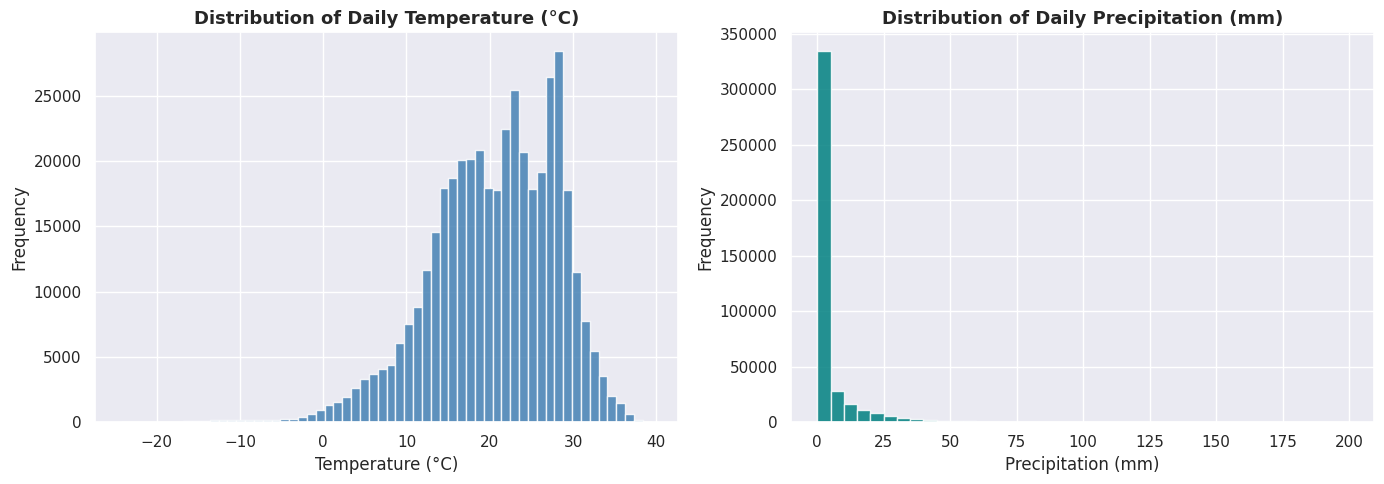

In [11]:
# Temperature Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Temp_2m'], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribution of Daily Temperature (°C)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Temperature (°C)')
axes[0].set_ylabel('Frequency')

axes[1].hist(df['Precip'], bins=40, color='teal', edgecolor='white', alpha=0.85)
axes[1].set_title('Distribution of Daily Precipitation (mm)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Precipitation (mm)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

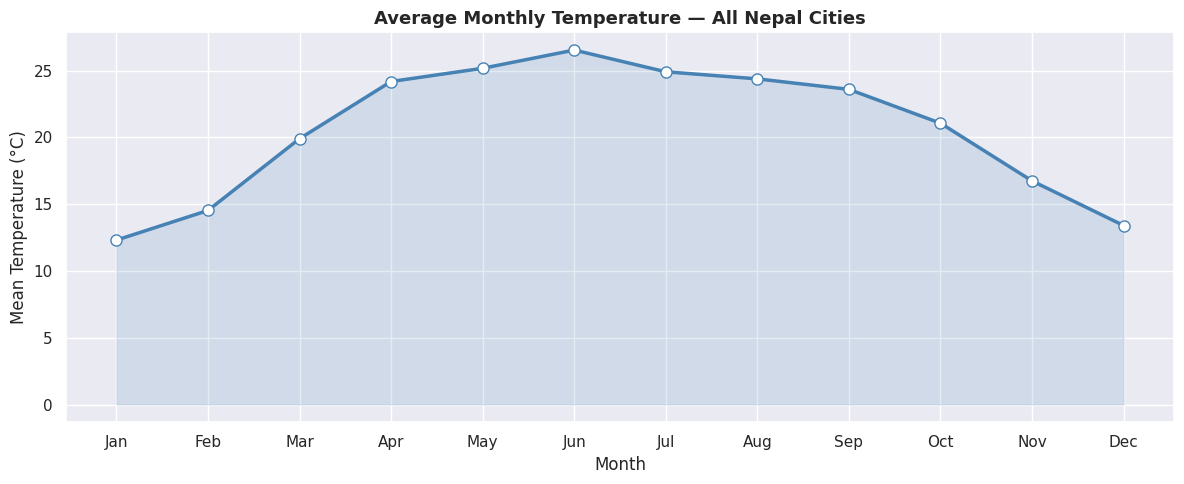

In [12]:
#  Monthly Average Temperature Across All Cities
df['Month_num'] = df['Date'].dt.month
monthly_temp = df.groupby('Month_num')['Temp_2m'].mean()

month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
plt.figure(figsize=(12, 5))
plt.plot(month_labels, monthly_temp.values, marker='o', linewidth=2.5,
         color='steelblue', markerfacecolor='white', markersize=8)
plt.fill_between(month_labels, monthly_temp.values, alpha=0.15, color='steelblue')
plt.title('Average Monthly Temperature — All Nepal Cities', fontsize=13, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Mean Temperature (°C)')
plt.tight_layout()
plt.show()

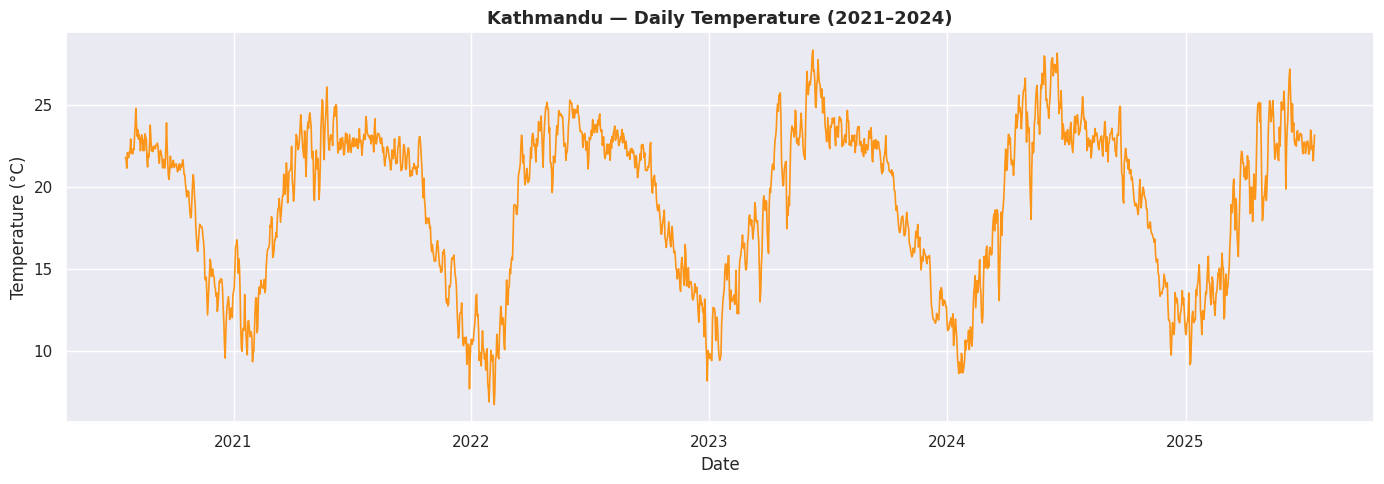

In [13]:
# City Sample — Kathmandu Temperature Time-Series
ktm = df[df['City'] == 'Kathmandu'].copy()

plt.figure(figsize=(14, 5))
plt.plot(ktm['Date'], ktm['Temp_2m'], linewidth=1.2, color='darkorange', alpha=0.9)
plt.title('Kathmandu — Daily Temperature (2021–2024)', fontsize=13, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

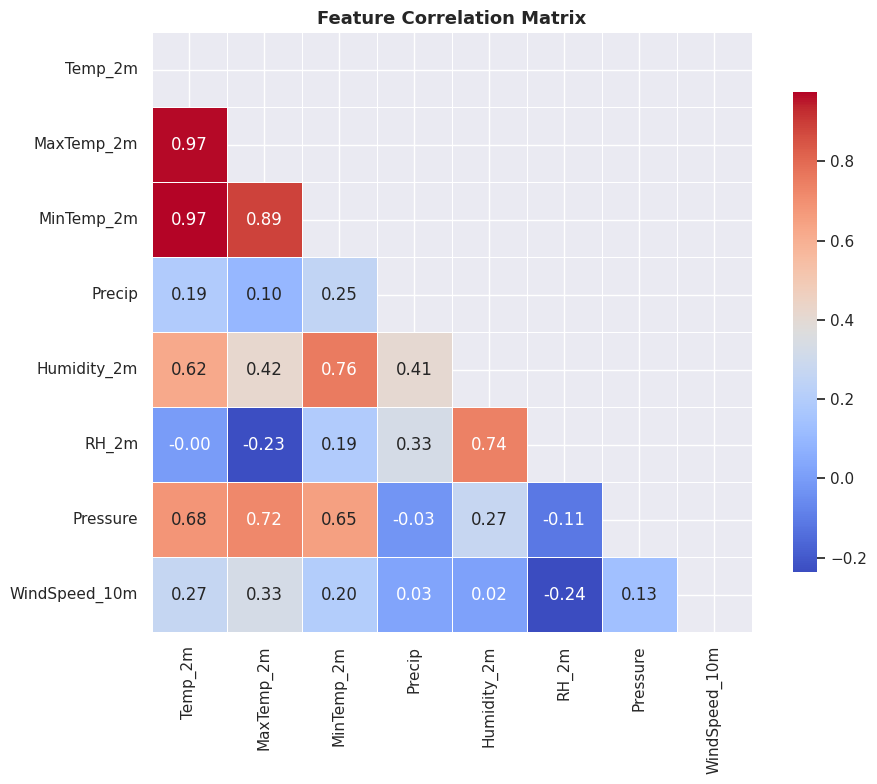

In [14]:
# Correlation Heatmap
num_cols = ['Temp_2m', 'MaxTemp_2m', 'MinTemp_2m', 'Precip',
            'Humidity_2m', 'RH_2m', 'Pressure', 'WindSpeed_10m']

plt.figure(figsize=(10, 8))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

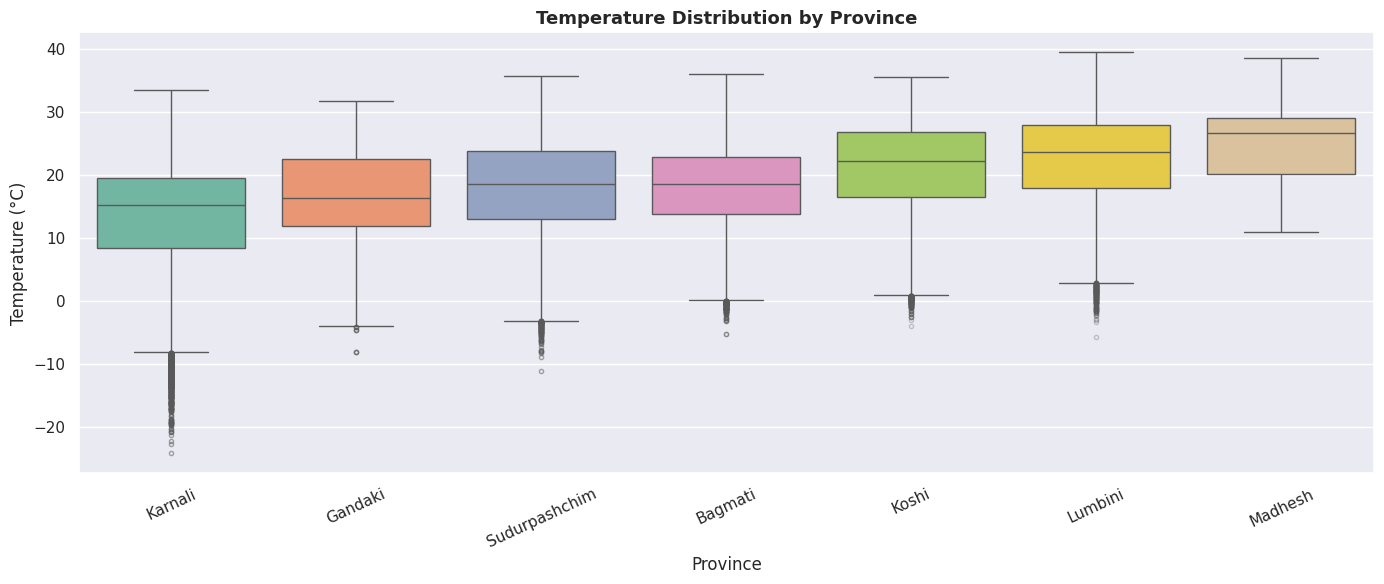

In [15]:
# Province-level Temperature Box Plot
province_order = df.groupby('Province')['Temp_2m'].median().sort_values().index.tolist()

plt.figure(figsize=(14, 6))
sns.boxplot(data=df, x='Province', y='Temp_2m', order=province_order,
            palette='Set2', flierprops=dict(marker='.', alpha=0.3))
plt.title('Temperature Distribution by Province', fontsize=13, fontweight='bold')
plt.xlabel('Province')
plt.ylabel('Temperature (°C)')
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

## 6. Date/Time Processing

In [16]:
# Extract Temporal Components
df['Year']       = df['Date'].dt.year
df['Month']      = df['Date'].dt.month
df['Day']        = df['Date'].dt.day
df['DayOfYear']  = df['Date'].dt.dayofyear
df['DayOfWeek']  = df['Date'].dt.dayofweek    # Monday=0, Sunday=6
df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)
df['Quarter']    = df['Date'].dt.quarter

# Season Encoding
def get_season(month):
    if month in [12, 1, 2]: return 'Winter'
    elif month in [3, 4, 5]: return 'Spring'
    elif month in [6, 7, 8]: return 'Summer'
    else: return 'Autumn'

df['Season'] = df['Month'].apply(get_season)

print('✅ Temporal features added:')
print(df[['Date', 'Year', 'Month', 'Day', 'DayOfYear', 'DayOfWeek', 'WeekOfYear', 'Quarter', 'Season']].head(8))

✅ Temporal features added:
        Date  Year  Month  Day  DayOfYear  DayOfWeek  WeekOfYear  Quarter  \
0 2020-07-19  2020      7   19        201          6          29        3   
1 2020-07-20  2020      7   20        202          0          30        3   
2 2020-07-21  2020      7   21        203          1          30        3   
3 2020-07-22  2020      7   22        204          2          30        3   
4 2020-07-23  2020      7   23        205          3          30        3   
5 2020-07-24  2020      7   24        206          4          30        3   
6 2020-07-25  2020      7   25        207          5          30        3   
7 2020-07-26  2020      7   26        208          6          30        3   

   Season  
0  Summer  
1  Summer  
2  Summer  
3  Summer  
4  Summer  
5  Summer  
6  Summer  
7  Summer  


## 7. Feature Engineering

In [17]:
#  Cyclical Encoding
# Standard meteorological practice: encode circular time features as sin/cos
# This prevents the model from thinking Dec 31 and Jan 1 are far apart.

df['Month_sin']      = np.sin(2 * np.pi * df['Month'] / 12)
df['Month_cos']      = np.cos(2 * np.pi * df['Month'] / 12)
df['DayOfYear_sin']  = np.sin(2 * np.pi * df['DayOfYear'] / 365.25)
df['DayOfYear_cos']  = np.cos(2 * np.pi * df['DayOfYear'] / 365.25)
df['DayOfWeek_sin']  = np.sin(2 * np.pi * df['DayOfWeek'] / 7)
df['DayOfWeek_cos']  = np.cos(2 * np.pi * df['DayOfWeek'] / 7)

print('✅ Cyclical features engineered:')
df[['Month_sin', 'Month_cos', 'DayOfYear_sin', 'DayOfYear_cos']].describe()

✅ Cyclical features engineered:


,Month_sin,Month_cos,DayOfYear_sin,DayOfYear_cos
count,419637.0000,419637.0000,419637.0000,419637.0000
mean,-0.0215,0.0021,-0.0168,0.0007
std,0.7054,0.7085,0.7068,0.7072
min,-1.0000,-1.0000,-1.0000,-1.0000
25%,-0.8660,-0.5000,-0.7262,-0.7075
50%,-0.0000,-0.0000,-0.0387,0.0011
75%,0.5000,0.8660,0.6945,0.7120
max,1.0000,1.0000,1.0000,1.0000


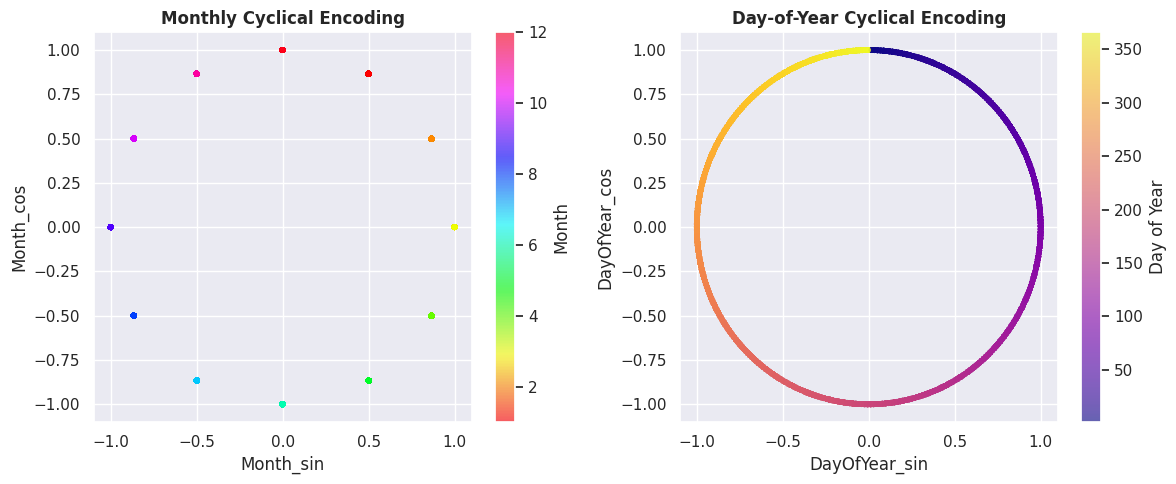

In [18]:
#  Visualise Cyclical Encoding
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

scatter_sample = df.sample(5000, random_state=42)
sc1 = axes[0].scatter(scatter_sample['Month_sin'], scatter_sample['Month_cos'],
                       c=scatter_sample['Month'], cmap='hsv', s=10, alpha=0.6)
axes[0].set_title('Monthly Cyclical Encoding', fontweight='bold')
axes[0].set_xlabel('Month_sin'); axes[0].set_ylabel('Month_cos')
plt.colorbar(sc1, ax=axes[0], label='Month')

sc2 = axes[1].scatter(scatter_sample['DayOfYear_sin'], scatter_sample['DayOfYear_cos'],
                       c=scatter_sample['DayOfYear'], cmap='plasma', s=10, alpha=0.6)
axes[1].set_title('Day-of-Year Cyclical Encoding', fontweight='bold')
axes[1].set_xlabel('DayOfYear_sin'); axes[1].set_ylabel('DayOfYear_cos')
plt.colorbar(sc2, ax=axes[1], label='Day of Year')

plt.tight_layout()
plt.show()

## 8. Lag Features

In [19]:
#  Lag Features (per-City grouping)
# Lag features give the model access to yesterday's weather,
# capturing autocorrelation (today ≈ tomorrow)

grouped = df.groupby('City')

# 1-day lags
df['Temp_2m_lag1']   = grouped['Temp_2m'].shift(1)
df['Precip_lag1']    = grouped['Precip'].shift(1)
df['RH_2m_lag1']     = grouped['RH_2m'].shift(1)
df['Humidity_lag1']  = grouped['Humidity_2m'].shift(1)
df['Pressure_lag1']  = grouped['Pressure'].shift(1)

# 7-day lags (same weekday last week)
df['Temp_2m_lag7']   = grouped['Temp_2m'].shift(7)
df['Precip_lag7']    = grouped['Precip'].shift(7)

print('✅ Lag features created:')
lag_cols = [c for c in df.columns if 'lag' in c]
print(lag_cols)
df[['Date', 'City', 'Temp_2m'] + lag_cols[:4]].head(10)

✅ Lag features created:
['Temp_2m_lag1', 'Precip_lag1', 'RH_2m_lag1', 'Humidity_lag1', 'Pressure_lag1', 'Temp_2m_lag7', 'Precip_lag7']


,Date,City,Temp_2m,Temp_2m_lag1,Precip_lag1,RH_2m_lag1,Humidity_lag1
0,2020-07-19,Aathabis,18.3400,NaN,NaN,NaN,NaN
1,2020-07-20,Aathabis,19.0500,18.3400,7.0000,92.4400,15.9000
2,2020-07-21,Aathabis,17.8300,19.0500,15.0000,92.8600,16.7200
3,2020-07-22,Aathabis,17.3500,17.8300,14.0000,89.7200,14.8500
4,2020-07-23,Aathabis,17.0800,17.3500,8.7000,85.9700,13.7900
5,2020-07-24,Aathabis,16.9900,17.0800,6.5000,89.2300,14.1400
6,2020-07-25,Aathabis,17.7400,16.9900,7.3000,88.2500,13.8200
7,2020-07-26,Aathabis,17.9300,17.7400,0.0000,91.5800,15.0200
8,2020-07-27,Aathabis,18.2200,17.9300,9.6000,89.8700,14.9100
9,2020-07-28,Aathabis,18.5100,18.2200,0.0000,89.2000,15.2100


## 9. Rolling Features

In [20]:
#  Rolling Statistics (per-City grouping)
# Rolling averages smooth short-term noise and capture medium-term trends.

# 3-day rolling means
df['Temp_2m_roll3']   = grouped['Temp_2m'].transform(lambda x: x.rolling(3,  min_periods=1).mean())
df['Precip_roll3']    = grouped['Precip'].transform(  lambda x: x.rolling(3,  min_periods=1).mean())
df['RH_2m_roll3']     = grouped['RH_2m'].transform(   lambda x: x.rolling(3,  min_periods=1).mean())

# 7-day rolling means
df['Temp_2m_roll7']   = grouped['Temp_2m'].transform(lambda x: x.rolling(7,  min_periods=1).mean())
df['Precip_roll7']    = grouped['Precip'].transform(  lambda x: x.rolling(7,  min_periods=1).mean())

# 14-day rolling mean
df['Temp_2m_roll14']  = grouped['Temp_2m'].transform(lambda x: x.rolling(14, min_periods=1).mean())

# Rolling standard deviation (variability signal)
df['Temp_2m_roll7_std'] = grouped['Temp_2m'].transform(lambda x: x.rolling(7, min_periods=2).std())

print('✅ Rolling features created:')
roll_cols = [c for c in df.columns if 'roll' in c]
print(roll_cols)
df[['Date', 'City', 'Temp_2m'] + roll_cols[:3]].head(10)

✅ Rolling features created:
['Temp_2m_roll3', 'Precip_roll3', 'RH_2m_roll3', 'Temp_2m_roll7', 'Precip_roll7', 'Temp_2m_roll14', 'Temp_2m_roll7_std']


,Date,City,Temp_2m,Temp_2m_roll3,Precip_roll3,RH_2m_roll3
0,2020-07-19,Aathabis,18.3400,18.3400,7.0000,92.4400
1,2020-07-20,Aathabis,19.0500,18.6950,11.0000,92.6500
2,2020-07-21,Aathabis,17.8300,18.4067,12.0000,91.6733
3,2020-07-22,Aathabis,17.3500,18.0767,12.5667,89.5167
4,2020-07-23,Aathabis,17.0800,17.4200,9.7333,88.3067
5,2020-07-24,Aathabis,16.9900,17.1400,7.5000,87.8167
6,2020-07-25,Aathabis,17.7400,17.2700,4.6000,89.6867
7,2020-07-26,Aathabis,17.9300,17.5533,5.6333,89.9000
8,2020-07-27,Aathabis,18.2200,17.9633,3.2000,90.2167
9,2020-07-28,Aathabis,18.5100,18.2200,24.3333,91.1833


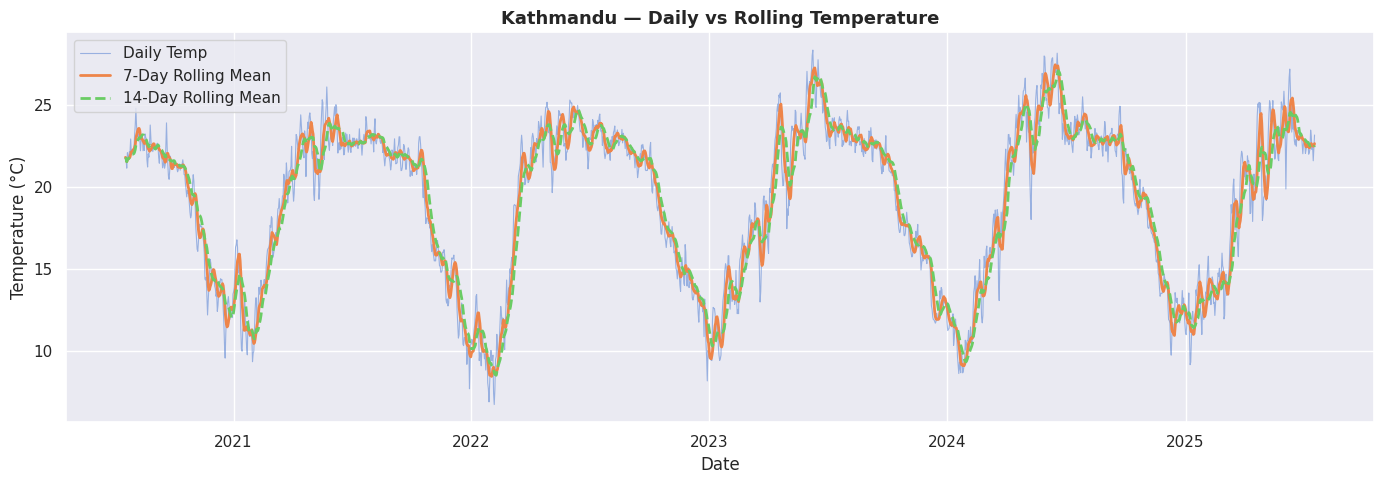

In [21]:
#  Visualise Lag vs Rolling Signal for Kathmandu
ktm = df[df['City'] == 'Kathmandu'].copy()

plt.figure(figsize=(14, 5))
plt.plot(ktm['Date'], ktm['Temp_2m'],       linewidth=0.8, alpha=0.5, label='Daily Temp')
plt.plot(ktm['Date'], ktm['Temp_2m_roll7'],  linewidth=2.0, label='7-Day Rolling Mean')
plt.plot(ktm['Date'], ktm['Temp_2m_roll14'], linewidth=2.0, linestyle='--', label='14-Day Rolling Mean')
plt.title('Kathmandu — Daily vs Rolling Temperature', fontsize=13, fontweight='bold')
plt.xlabel('Date'); plt.ylabel('Temperature (°C)')
plt.legend(); plt.tight_layout(); plt.show()

---
## 10. Target Selection

In [22]:
#  Create Prediction Targets (next-day values)
# We shift by -1 within each city group to get the NEXT day's observation.
df['Temp_2m_tomorrow']   = grouped['Temp_2m'].shift(-1)
df['Precip_tomorrow']    = grouped['Precip'].shift(-1)
df['RH_2m_tomorrow']     = grouped['RH_2m'].shift(-1)

#  Feature List
FEATURES = [
    'Latitude', 'Longitude',
    'Temp_2m', 'MaxTemp_2m', 'MinTemp_2m',
    'Precip', 'RH_2m', 'Pressure',
    'Month_sin', 'Month_cos',
    'DayOfYear_sin', 'DayOfYear_cos',
    'DayOfWeek_sin', 'DayOfWeek_cos',
    'Temp_2m_lag1', 'Precip_lag1', 'RH_2m_lag1',
    'Temp_2m_roll3', 'Temp_2m_roll7', 'Temp_2m_roll14',
    'Precip_roll3', 'RH_2m_roll3'
]

TARGETS = ['Temp_2m_tomorrow', 'Precip_tomorrow', 'RH_2m_tomorrow']

print(f'Total features : {len(FEATURES)}')
print(f'Target columns : {TARGETS}')
print(f'\nFeature list:')
for i, f in enumerate(FEATURES, 1):
    print(f'  {i:2d}. {f}')

Total features : 22
Target columns : ['Temp_2m_tomorrow', 'Precip_tomorrow', 'RH_2m_tomorrow']

Feature list:
   1. Latitude
   2. Longitude
   3. Temp_2m
   4. MaxTemp_2m
   5. MinTemp_2m
   6. Precip
   7. RH_2m
   8. Pressure
   9. Month_sin
  10. Month_cos
  11. DayOfYear_sin
  12. DayOfYear_cos
  13. DayOfWeek_sin
  14. DayOfWeek_cos
  15. Temp_2m_lag1
  16. Precip_lag1
  17. RH_2m_lag1
  18. Temp_2m_roll3
  19. Temp_2m_roll7
  20. Temp_2m_roll14
  21. Precip_roll3
  22. RH_2m_roll3


In [23]:
#  Drop Rows with NaN in Features or Targets
df_model = df.dropna(subset=FEATURES + TARGETS).copy()

print(f'Rows before dropna : {len(df):,}')
print(f'Rows after  dropna : {len(df_model):,}')
print(f'Rows dropped       : {len(df) - len(df_model):,}')

Rows before dropna : 419,637
Rows after  dropna : 419,088
Rows dropped       : 549


## 11. Train / Validation / Test Split

In [24]:
#  Chronological (Time-Series) Split
# CRITICAL: Always split by time — never random split for time-series.
# Using future data to train = data leakage → inflated metrics.
#
# Timeline:
#   2021 – 2022  →  Training   (~50%)
#   2023         →  Validation (~25%)
#   2024         →  Test       (~25%)

train_df = df_model[df_model['Year'] <= 2022].copy()
val_df   = df_model[df_model['Year'] == 2023].copy()
test_df  = df_model[df_model['Year'] == 2024].copy()

X_train, y_train = train_df[FEATURES], train_df[TARGETS]
X_val,   y_val   = val_df[FEATURES],   val_df[TARGETS]
X_test,  y_test  = test_df[FEATURES],  test_df[TARGETS]

print('=== Split Summary ===')
print(f'Train set   : {len(X_train):>8,} rows  (Years ≤ 2022)')
print(f'Val set     : {len(X_val):>8,} rows  (Year  = 2023)')
print(f'Test set    : {len(X_test):>8,} rows  (Year  = 2024)')
print(f'\nTrain %     : {100*len(X_train)/len(df_model):.1f}%')
print(f'Val   %     : {100*len(X_val)/len(df_model):.1f}%')
print(f'Test  %     : {100*len(X_test)/len(df_model):.1f}%')

=== Split Summary ===
Train set   :  221,954 rows  (Years ≤ 2022)
Val set     :   77,015 rows  (Year  = 2023)
Test set    :   77,226 rows  (Year  = 2024)

Train %     : 53.0%
Val   %     : 18.4%
Test  %     : 18.4%


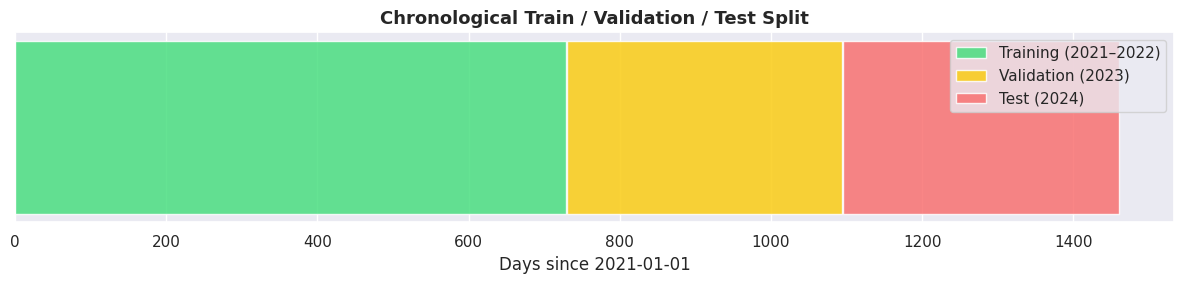

In [25]:
#  Visualise Split Timeline
fig, ax = plt.subplots(figsize=(12, 3))

splits = [
    ('Training (2021–2022)',  '2021-01-01', '2022-12-31', '#4ade80'),
    ('Validation (2023)',     '2023-01-01', '2023-12-31', '#facc15'),
    ('Test (2024)',           '2024-01-01', '2024-12-31', '#f87171'),
]
for label, start, end, color in splits:
    ax.barh(0, (pd.Timestamp(end) - pd.Timestamp(start)).days,
            left=(pd.Timestamp(start) - pd.Timestamp('2021-01-01')).days,
            height=0.5, color=color, alpha=0.85, label=label)

ax.set_yticks([])
ax.set_xlabel('Days since 2021-01-01')
ax.set_title('Chronological Train / Validation / Test Split', fontsize=13, fontweight='bold')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

## 12. Preprocessing Pipeline

In [26]:
#  StandardScaler (for SVR — tree models don't require scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print('✅ Feature scaling applied (StandardScaler)')
print(f'   Mean (first 3 features): {X_train_scaled.mean(axis=0)[:3].round(4)}')
print(f'   Std  (first 3 features): {X_train_scaled.std(axis=0)[:3].round(4)}')

✅ Feature scaling applied (StandardScaler)
   Mean (first 3 features): [-0. -0.  0.]
   Std  (first 3 features): [1. 1. 1.]


In [27]:
#  Helper: Evaluation Function
def evaluate(y_true, y_pred, label=''):
    """Compute MAE, RMSE, and R² for a single target column."""
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    if label:
        print(f'  {label:<35}  MAE={mae:.4f}  RMSE={rmse:.4f}  R²={r2:.4f}')
    return {'mae': mae, 'rmse': rmse, 'r2': r2}

# Storage for results
results = {}   # results[target][model_name] = metrics dict

print('✅ Evaluation helper ready.')

✅ Evaluation helper ready.


## 13. Decision Tree

In [28]:
#  Decision Tree Regressor
# Fast, interpretable baseline. Decision Trees tend to overfit;
# we use max_depth to regularise.

print('Training Decision Tree … (may take a moment for large dataset)')

dt_models = {}
for target in TARGETS:
    dt = DecisionTreeRegressor(
        max_depth=10,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42
    )
    dt.fit(X_train, y_train[target])
    dt_models[target] = dt
    preds = dt.predict(X_val)
    metrics = evaluate(y_val[target], preds, label=f'DecisionTree → {target}')
    results.setdefault(target, {})['Decision Tree'] = metrics

print('\n✅ Decision Tree training complete.')

Training Decision Tree … (may take a moment for large dataset)
  DecisionTree → Temp_2m_tomorrow      MAE=0.7348  RMSE=0.9987  R²=0.9828
  DecisionTree → Precip_tomorrow       MAE=4.1158  RMSE=8.8261  R²=0.2290
  DecisionTree → RH_2m_tomorrow        MAE=4.4216  RMSE=6.1748  R²=0.9035

✅ Decision Tree training complete.


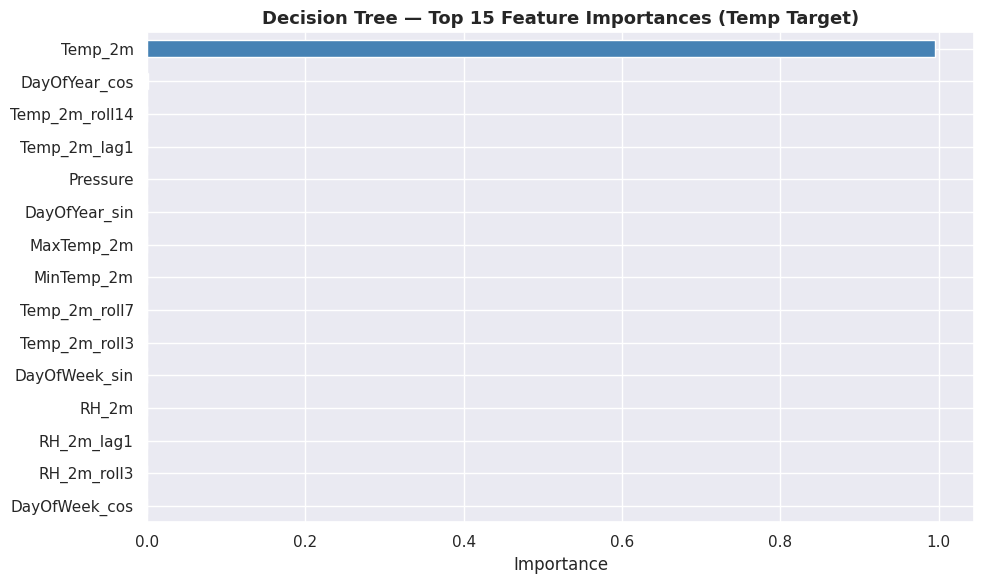

In [29]:
# Feature Importances (Temp target)
importances = pd.Series(dt_models['Temp_2m_tomorrow'].feature_importances_, index=FEATURES)
top_feats   = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
top_feats[::-1].plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Decision Tree — Top 15 Feature Importances (Temp Target)', fontsize=13, fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## 14. Random Forest

In [ ]:
#  Random Forest Regressor
# Ensemble of many Decision Trees — reduces overfitting via averaging.
# Typically the best performer for tabular weather data.

print('Training Random Forest … (may take several minutes)')

rf_models = {}
for target in TARGETS:
    rf = RandomForestRegressor(
        n_estimators=100,
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1          # use all CPU cores
    )
    rf.fit(X_train, y_train[target])
    rf_models[target] = rf
    preds = rf.predict(X_val)
    metrics = evaluate(y_val[target], preds, label=f'RandomForest → {target}')
    results[target]['Random Forest'] = metrics

print('\n✅ Random Forest training complete.')

Training Random Forest … (may take several minutes)
  RandomForest → Temp_2m_tomorrow      MAE=0.7021  RMSE=0.9355  R²=0.9849
  RandomForest → Precip_tomorrow       MAE=4.1364  RMSE=8.6847  R²=0.2534
  RandomForest → RH_2m_tomorrow        MAE=4.1006  RMSE=5.6945  R²=0.9179

✅ Random Forest training complete.


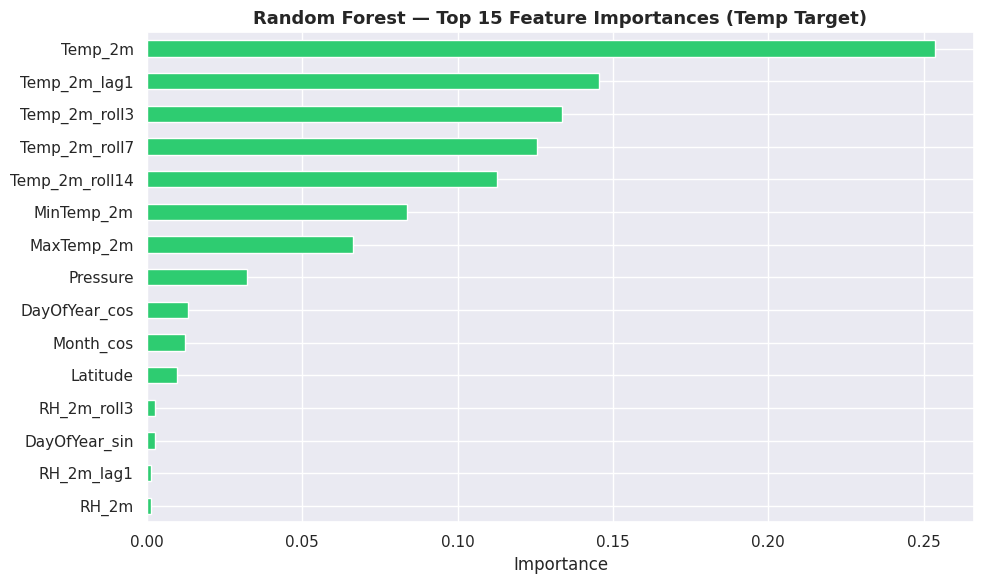

In [ ]:
# ── Feature Importances — Random Forest ───────────────────────────────────────
rf_importances = pd.Series(
    rf_models['Temp_2m_tomorrow'].feature_importances_, index=FEATURES
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
rf_importances.head(15)[::-1].plot(kind='barh', color='#2ecc71', edgecolor='white')
plt.title('Random Forest — Top 15 Feature Importances (Temp Target)', fontsize=13, fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## 15. SVM (SVR)

In [ ]:
#  Support Vector Regression (SVR)
# SVR works best on scaled data and smaller datasets.
# We train on a stratified sample to keep training time manageable.

print('Training SVR on a 50,000-row sample (SVR does not scale to full dataset) …')

# Sample training data for speed
sample_size = min(50_000, len(X_train))
sample_idx  = np.random.default_rng(42).choice(len(X_train), size=sample_size, replace=False)
X_svr_train = X_train_scaled[sample_idx]

svr_models = {}
for target in TARGETS:
    y_svr_train = y_train[target].iloc[sample_idx]
    svr = SVR(kernel='rbf', C=10, gamma='scale', epsilon=0.1)
    svr.fit(X_svr_train, y_svr_train)
    svr_models[target] = svr
    preds = svr.predict(X_val_scaled)
    metrics = evaluate(y_val[target], preds, label=f'SVR → {target}')
    results[target]['SVR'] = metrics

print('\n✅ SVR training complete.')

## 16. Hyperparameter Tuning

In [ ]:
#  RandomizedSearchCV for Random Forest (Temp target)
# We tune the best-performing model (Random Forest) for the primary target.
# RandomizedSearch is preferred over GridSearch for large parameter spaces.

print('Running RandomizedSearchCV for Random Forest (Temp_2m_tomorrow) …')

param_dist = {
    'n_estimators':    [50, 100, 200],
    'max_depth':       [8, 12, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':    ['sqrt', 'log2', 0.5]
}

# Sub-sample training set for faster tuning
tune_size = min(80_000, len(X_train))
tune_idx  = np.random.default_rng(0).choice(len(X_train), size=tune_size, replace=False)
X_tune = X_train.iloc[tune_idx]
y_tune = y_train['Temp_2m_tomorrow'].iloc[tune_idx]

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)
rf_search.fit(X_tune, y_tune)

print(f'\n✅ Best parameters found:')
for k, v in rf_search.best_params_.items():
    print(f'   {k}: {v}')
print(f'\nBest CV RMSE: {-rf_search.best_score_:.4f}°C')

In [ ]:
#  Train Tuned Model on Full Training Set
best_rf_temp = rf_search.best_estimator_
best_rf_temp.fit(X_train, y_train['Temp_2m_tomorrow'])

tuned_preds = best_rf_temp.predict(X_val)
tuned_metrics = evaluate(y_val['Temp_2m_tomorrow'], tuned_preds, label='Tuned RF → Temp_2m_tomorrow')
results['Temp_2m_tomorrow']['Tuned Random Forest'] = tuned_metrics

# Replace the rf_model for Temp with the tuned version
rf_models['Temp_2m_tomorrow'] = best_rf_temp

print('\n✅ Tuned model ready.')

## 17. Model Evaluation

In [ ]:
#  Full Evaluation on Held-Out Test Set (2024)
print('=== TEST SET EVALUATION (Year 2024) ===\n')

test_results = {}
model_map = {
    'Decision Tree':   (dt_models, X_test, False),
    'Random Forest':   (rf_models, X_test, False),
    'SVR':             (svr_models, X_test_scaled, True),
}

for model_name, (model_dict, X_eval, _) in model_map.items():
    print(f'--- {model_name} ---')
    test_results[model_name] = {}
    for target in TARGETS:
        preds = model_dict[target].predict(X_eval)
        m = evaluate(y_test[target], preds, label=f'  {target}')
        test_results[model_name][target] = m
    print()

In [ ]:
#  Residual Plot — Best Model (Temp target)
rf_preds_test = rf_models['Temp_2m_tomorrow'].predict(X_test)
residuals     = y_test['Temp_2m_tomorrow'].values - rf_preds_test

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: Actual vs Predicted
axes[0].scatter(y_test['Temp_2m_tomorrow'].values, rf_preds_test,
                alpha=0.2, s=5, color='steelblue')
lim = [y_test['Temp_2m_tomorrow'].min(), y_test['Temp_2m_tomorrow'].max()]
axes[0].plot(lim, lim, 'r--', linewidth=1.5)
axes[0].set_title('Actual vs Predicted Temperature', fontweight='bold')
axes[0].set_xlabel('Actual (°C)'); axes[0].set_ylabel('Predicted (°C)')

# Residual histogram
axes[1].hist(residuals, bins=80, color='teal', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', linewidth=1.5, linestyle='--')
axes[1].set_title('Residual Distribution (Pred − Actual)', fontweight='bold')
axes[1].set_xlabel('Residual (°C)'); axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## 18. Model Comparison

In [ ]:
#  Build Comparison DataFrame
rows = []
for model_name, targets_dict in test_results.items():
    for target, m in targets_dict.items():
        rows.append({'Model': model_name, 'Target': target,
                     'MAE': m['mae'], 'RMSE': m['rmse'], 'R²': m['r2']})

compare_df = pd.DataFrame(rows)
print('=== Model Comparison Table (Test Set) ===')
display(compare_df.sort_values(['Target', 'RMSE']))

In [ ]:
# Bar Chart Comparison — RMSE per Target
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, target in zip(axes, TARGETS):
    subset = compare_df[compare_df['Target'] == target].sort_values('RMSE')
    colors = ['#2ecc71' if m == subset['Model'].iloc[0] else '#95a5a6'
              for m in subset['Model']]
    ax.bar(subset['Model'], subset['RMSE'], color=colors, edgecolor='white')
    ax.set_title(f'RMSE — {target}', fontweight='bold')
    ax.set_ylabel('RMSE')
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('Model Comparison — RMSE by Target (lower is better)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# R² Comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, target in zip(axes, TARGETS):
    subset = compare_df[compare_df['Target'] == target].sort_values('R²', ascending=False)
    colors = ['#3498db' if m == subset['Model'].iloc[0] else '#bdc3c7'
              for m in subset['Model']]
    ax.bar(subset['Model'], subset['R²'], color=colors, edgecolor='white')
    ax.set_ylim(0, 1)
    ax.set_title(f'R² — {target}', fontweight='bold')
    ax.set_ylabel('R² Score')
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('Model Comparison — R² by Target (higher is better)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 19. Select Best Model

In [ ]:
#  Select Best Model per Target (by lowest RMSE on test set)
best_models = {}

for target in TARGETS:
    subset = compare_df[compare_df['Target'] == target]
    best_row = subset.loc[subset['RMSE'].idxmin()]
    best_name = best_row['Model']

    # Retrieve the actual model object
    if best_name in ('Random Forest', 'Tuned Random Forest'):
        best_models[target] = rf_models[target]
    elif best_name == 'Decision Tree':
        best_models[target] = dt_models[target]
    elif best_name == 'SVR':
        best_models[target] = svr_models[target]

    print(f'✅ {target:<25} →  Best: {best_name}')
    print(f'   MAE={best_row["MAE"]:.4f}  RMSE={best_row["RMSE"]:.4f}  R²={best_row["R²"]:.4f}\n')

In [ ]:
#  Summary Card
print('=' * 60)
print('        FINAL MODEL SELECTION SUMMARY')
print('=' * 60)
print(f'{"Target":<28} {"Model":<22} {"R²":>6}')
print('-' * 60)
for target in TARGETS:
    row = compare_df[(compare_df['Target'] == target)].sort_values('RMSE').iloc[0]
    print(f'{target:<28} {row["Model"]:<22} {row["R²"]:>6.4f}')
print('=' * 60)

## 20. Future Forecasting (Multi-Target)

In [ ]:
#  Recursive 5-Day Forecast for a Chosen City
# Strategy: use the last known row for the city, then recursively predict
# the next day using the previous prediction as lag input.

FORECAST_CITY = 'Kathmandu'
FORECAST_DAYS = 5

# Get the most recent row for the city
city_data = df_model[df_model['City'] == FORECAST_CITY].sort_values('Date')
last_row  = city_data.iloc[-1].copy()
last_date = last_row['Date']

print(f'Generating {FORECAST_DAYS}-day forecast for: {FORECAST_CITY}')
print(f'Starting from: {last_date.date()}\n')

forecasts = []
current   = last_row.copy()

for day in range(1, FORECAST_DAYS + 1):
    forecast_date = last_date + pd.Timedelta(days=day)

    # Update temporal features for the forecast date
    current['Month']         = forecast_date.month
    current['Day']           = forecast_date.day
    current['DayOfYear']     = forecast_date.dayofyear
    current['DayOfWeek']     = forecast_date.dayofweek
    current['Month_sin']     = np.sin(2 * np.pi * forecast_date.month / 12)
    current['Month_cos']     = np.cos(2 * np.pi * forecast_date.month / 12)
    current['DayOfYear_sin'] = np.sin(2 * np.pi * forecast_date.dayofyear / 365.25)
    current['DayOfYear_cos'] = np.cos(2 * np.pi * forecast_date.dayofyear / 365.25)
    current['DayOfWeek_sin'] = np.sin(2 * np.pi * forecast_date.dayofweek / 7)
    current['DayOfWeek_cos'] = np.cos(2 * np.pi * forecast_date.dayofweek / 7)

    X_pred = current[FEATURES].values.reshape(1, -1)

    pred_temp   = best_models['Temp_2m_tomorrow'].predict(X_pred)[0]
    pred_precip = best_models['Precip_tomorrow'].predict(X_pred)[0]
    pred_rh     = best_models['RH_2m_tomorrow'].predict(X_pred)[0]

    forecasts.append({
        'Date':        forecast_date.date(),
        'Temp_2m':     round(pred_temp, 2),
        'Precip':      round(max(0, pred_precip), 2),
        'RH_2m':       round(np.clip(pred_rh, 0, 100), 1)
    })

    # Feed predictions back as lag features for next iteration
    current['Temp_2m_lag1'] = pred_temp
    current['Precip_lag1']  = pred_precip
    current['RH_2m_lag1']   = pred_rh
    current['Temp_2m']      = pred_temp
    current['Precip']       = pred_precip
    current['RH_2m']        = pred_rh

forecast_df = pd.DataFrame(forecasts)
print(f'5-Day Forecast for {FORECAST_CITY}:')
display(forecast_df)

In [ ]:
#  Visualise Forecast
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

dates     = forecast_df['Date'].astype(str)
plot_data = [
    ('Temp_2m', 'Temperature (°C)', 'steelblue'),
    ('Precip',  'Precipitation (mm)', 'teal'),
    ('RH_2m',   'Relative Humidity (%)', 'darkorchid'),
]

for ax, (col, ylabel, color) in zip(axes, plot_data):
    ax.bar(dates, forecast_df[col], color=color, alpha=0.8, edgecolor='white')
    ax.set_ylabel(ylabel, fontweight='bold')
    ax.tick_params(axis='x', rotation=20)

axes[0].set_title(f'{FORECAST_CITY} — {FORECAST_DAYS}-Day Multi-Target Forecast',
                  fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
#  24-Hour Diurnal Curve (Mathematical Approximation)
# Since dataset is daily frequency, we generate a realistic 24-hour temperature
# curve using a sine-wave model based on meteorological principles.

T_pred = forecast_df['Temp_2m'].iloc[0]          # tomorrow's predicted mean
T_max  = T_pred + 4.0                             # estimated max
T_min  = T_pred - 4.0                             # estimated min

hours = np.arange(0, 24, 0.5)
T_diurnal = (T_max + T_min) / 2 + (T_max - T_min) / 2 * np.sin(
    np.pi * (hours - 5) / 12
)

plt.figure(figsize=(12, 5))
plt.plot(hours, T_diurnal, linewidth=2.5, color='darkorange')
plt.fill_between(hours, T_min, T_diurnal, alpha=0.15, color='darkorange')
plt.axhline(T_pred, color='gray', linewidth=1, linestyle='--', label=f'Predicted Mean: {T_pred:.1f}°C')
plt.title(f'{FORECAST_CITY} — 24-Hour Diurnal Temperature Curve (Day 1 Forecast)',
          fontsize=13, fontweight='bold')
plt.xlabel('Hour of Day'); plt.ylabel('Temperature (°C)')
plt.xticks(range(0, 25, 2))
plt.legend(); plt.tight_layout(); plt.show()

## 21. Save Models

In [ ]:
# Persist Best Models & Feature List
os.makedirs(MODEL_DIR, exist_ok=True)

# Save each target's best model
for target, model in best_models.items():
    out_path = os.path.join(MODEL_DIR, f'model_{target}.pkl')
    joblib.dump(model, out_path)
    size_kb = os.path.getsize(out_path) / 1024
    print(f'✅ Saved: {out_path}  ({size_kb:,.0f} KB)')

# Save feature column list (needed at inference time)
feat_path = os.path.join(MODEL_DIR, 'feature_columns.pkl')
joblib.dump(FEATURES, feat_path)
print(f'✅ Saved: {feat_path}')

# Save the StandardScaler (needed for SVR at inference)
scaler_path = os.path.join(MODEL_DIR, 'scaler.pkl')
joblib.dump(scaler, scaler_path)
print(f'✅ Saved: {scaler_path}')

print(f'\nAll artefacts saved to: {os.path.abspath(MODEL_DIR)}')

## 22. Test Saved Model

In [ ]:
#  Load Models from Disk & Verify
print('Loading saved models from disk …')

loaded_features = joblib.load(os.path.join(MODEL_DIR, 'feature_columns.pkl'))
loaded_models   = {}
for target in TARGETS:
    path = os.path.join(MODEL_DIR, f'model_{target}.pkl')
    loaded_models[target] = joblib.load(path)
    print(f'  ✅ Loaded: {path}')

print(f'\nFeature columns loaded: {len(loaded_features)}')

In [ ]:
#  Sanity Check — Predictions on Test Set
print('=== Sanity Check: Loaded Models on Test Set ===')

for target in TARGETS:
    preds = loaded_models[target].predict(X_test[loaded_features])
    evaluate(y_test[target], preds, label=f'Loaded model → {target}')

print('\n✅ Predictions match — saved models are valid!')

In [ ]:
#  Quick Single-Row Inference Demo
# Simulates what app.py does at runtime: takes the last known row for a city
# and returns next-day predictions.

demo_city = 'Pokhara'
demo_row  = df_model[df_model['City'] == demo_city].sort_values('Date').iloc[-1]

X_demo = demo_row[loaded_features].values.reshape(1, -1)

print(f'--- Single Inference Demo: {demo_city} ---')
print(f'Input date : {demo_row["Date"].date()}')
print()
for target in TARGETS:
    pred = loaded_models[target].predict(X_demo)[0]
    print(f'  Predicted {target:<25}: {pred:.3f}')

print('\n✅ Single-row inference successful — pipeline end-to-end complete!')